# Modelos de Predicción de Crédito

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    cohen_kappa_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

In [67]:
df = pd.read_excel("Credito.xlsx", sheet_name='Credito')
df = df.drop(columns=["ID"])

In [68]:
print(df.shape)
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

(750, 16)
Credito            int64
Sexo               int64
Casado             int64
Educacion          int64
Prioridad          int64
Historial        float64
Ubicacion          int64
Independiente    float64
Hijos            float64
Tarjetas           int64
Edad             float64
Deuda            float64
Saldo              int64
CrediScore         int64
Años_empleo      float64
Ingresos           int64
dtype: object

Missing values:
Credito           0
Sexo              0
Casado            0
Educacion         0
Prioridad         0
Historial        46
Ubicacion         0
Independiente    35
Hijos            15
Tarjetas          0
Edad              8
Deuda             0
Saldo             0
CrediScore        0
Años_empleo      32
Ingresos          0
dtype: int64


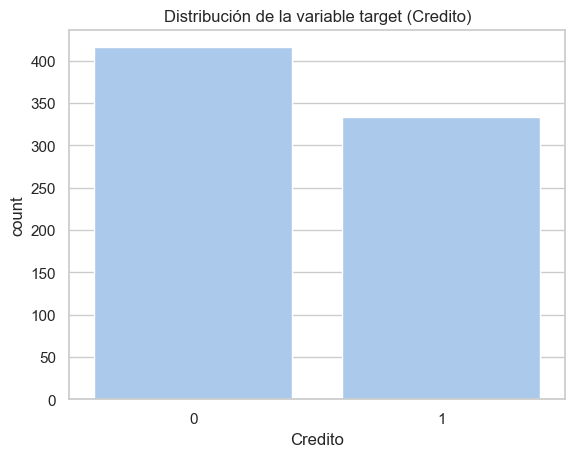

In [69]:
sns.countplot(data=df, x="Credito")
plt.title("Distribución de la variable target (Credito)")
plt.show()

C:\Users\march\AppData\Local\Temp\ipykernel_9100\710915948.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Credito", y=var, ax=axes[i], palette="Set2")
C:\Users\march\AppData\Local\Temp\ipykernel_9100\710915948.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Credito", y=var, ax=axes[i], palette="Set2")
C:\Users\march\AppData\Local\Temp\ipykernel_9100\710915948.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Credito", y=var, ax=axes[i], palette="Set2")
C:\Users\march\AppData\Local\Temp\ipyker

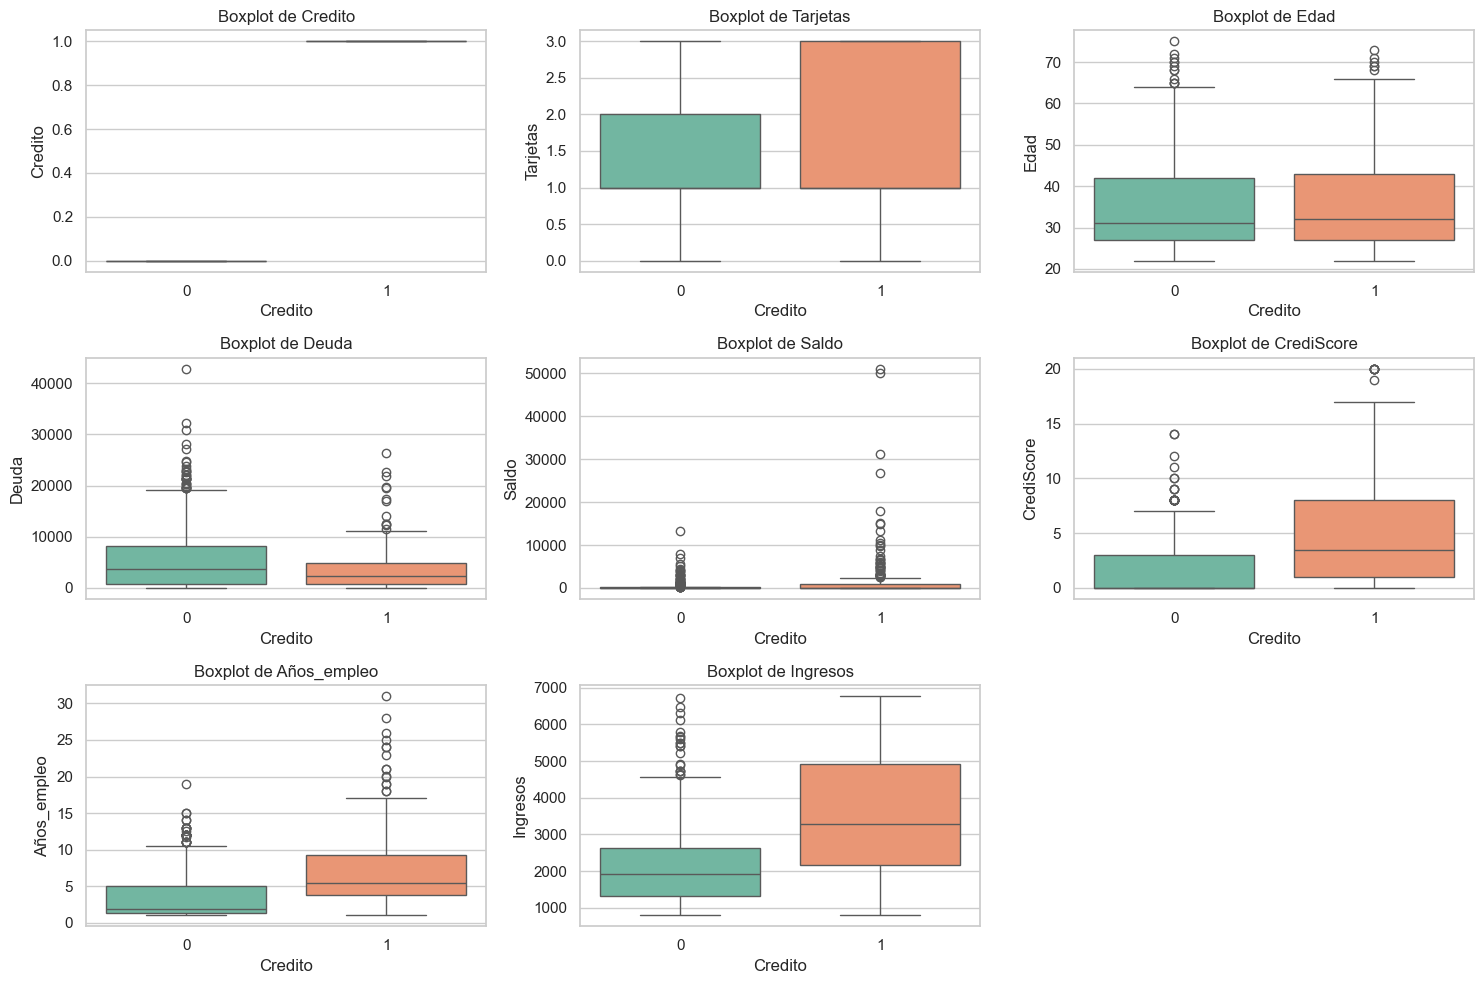

In [70]:
columnas_numericas = ["Tarjetas", "Edad", "Deuda", "Saldo", "CrediScore", "Años_empleo", "Ingresos"]
variables = ["Credito"] + columnas_numericas

n_cols = 3
n_rows = (len(variables) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.boxplot(data=df, x="Credito", y=var, ax=axes[i], palette="Set2")
    axes[i].set_title(f'Boxplot de {var}')
    axes[i].set_xlabel('Credito')
    axes[i].set_ylabel(var)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Train/Test Split (antes de cualquier preprocessing)

In [71]:
X = df.drop("Credito", axis=1)
Y = df["Credito"]

variables_categoricas = ["Sexo", "Casado", "Educacion", "Prioridad", "Historial", "Ubicacion", "Independiente", "Hijos"]
variables_numericas = ["Tarjetas", "Edad", "Deuda", "Saldo", "CrediScore", "Años_empleo", "Ingresos"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=120, stratify=Y
)

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")
print(f"Distribución target (entrenamiento): {Y_train.value_counts().to_dict()}")
print(f"Distribución target (prueba): {Y_test.value_counts().to_dict()}")

Entrenamiento: (600, 15), Prueba: (150, 15)
Distribución target (entrenamiento): {0: 333, 1: 267}
Distribución target (prueba): {0: 83, 1: 67}


In [72]:
# Snapshot de métricas previas (si existen)
prev_all_metrics = globals().get('all_metrics', None)
print('PREV_ALL_METRICS:', prev_all_metrics)

PREV_ALL_METRICS: {'DecisionTree': {'Exactitud': 0.8, 'AUC': 0.829077504046035, 'Kappa': 0.5918737529475784, 'Precisión (PPV)': 0.8032786885245902, 'Sensibilidad (Recall)': np.float64(0.7313432835820896), 'F1': 0.765625, 'Especificidad': np.float64(0.8554216867469879)}, 'RandomForest': {'Exactitud': 0.9, 'AUC': 0.9376910627584967, 'Kappa': 0.7974068071312804, 'Precisión (PPV)': 0.8939393939393939, 'Sensibilidad (Recall)': np.float64(0.8805970149253731), 'F1': 0.8872180451127819, 'Especificidad': np.float64(0.9156626506024096)}, 'Bagging': {'Exactitud': 0.86, 'AUC': 0.9219564826470059, 'Kappa': 0.7147255931896395, 'Precisión (PPV)': 0.8709677419354839, 'Sensibilidad (Recall)': np.float64(0.8059701492537313), 'F1': 0.8372093023255814, 'Especificidad': np.float64(0.9036144578313253)}, 'AdaBoost': {'Exactitud': 0.8333333333333334, 'AUC': 0.9096385542168675, 'Kappa': 0.6642793196060878, 'Precisión (PPV)': 0.8, 'Sensibilidad (Recall)': np.float64(0.835820895522388), 'F1': 0.8175182481751825,

## Pipeline de Preprocessing

Todo el preprocessing se encapsula en un Pipeline para evitar data leakage.

In [73]:
def make_transformer(cols_to_transform, func_dict):
    col_indices = {col: i for i, col in enumerate(cols_to_transform)}
    def transform_func(X):
        X_out = np.array(X, dtype=float).copy()
        for col, func in func_dict.items():
            if col in col_indices:
                idx = col_indices[col]
                X_out[:, idx] = func(X_out[:, idx])
        return X_out
    return FunctionTransformer(transform_func, feature_names_out='one-to-one')

def safe_sqrt(x):
    return np.sqrt(np.maximum(x, 0))

def safe_log1p(x):
    return np.log1p(np.maximum(x, 0))

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('transform', make_transformer(variables_numericas, {
        'Edad': safe_sqrt,
        'Deuda': safe_log1p,
        'Saldo': safe_log1p,
        'CrediScore': safe_log1p,
        'Años_empleo': safe_log1p,
        'Ingresos': safe_log1p,
    })),
])

preprocessor = ColumnTransformer([
    ('cat', cat_transformer, variables_categoricas),
    ('num', num_transformer, variables_numericas),
])

## Definición de Modelos y Grids

In [74]:
models_config = [
    (
        "DecisionTree",
        DecisionTreeClassifier(random_state=25),
        {
            'classifier__criterion': ["gini", "entropy"],
            'classifier__max_depth': [None, 2, 3],
            'classifier__min_samples_leaf': [1, 5],
        }
    ),
    (
        "RandomForest",
        RandomForestClassifier(n_estimators=300, n_jobs=-1, oob_score=True, random_state=25),
        {
            'classifier__max_features': ['sqrt', 'log2'],
        }
    ),
    (
        "Bagging",
        BaggingClassifier(random_state=27),
        {
            'classifier__max_features': [0.5, 0.7, 1.0],
            'classifier__max_samples': [0.5, 0.7, 1.0],
            'classifier__n_estimators': [5, 10, 20],
        }
    ),
    (
        "AdaBoost",
        AdaBoostClassifier(random_state=2),
        {
            'classifier__n_estimators': list(range(5, 40)),
        }
    ),
]

## Entrenamiento de Modelos

In [75]:
trained_models = {}

for name, estimator, param_grid in models_config:
    print(f"\nEntrenando {name}...")
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', estimator),
    ])

    grid_search = GridSearchCV(pipeline, param_grid, cv=10, n_jobs=-1)
    grid_search.fit(X_train, Y_train)

    trained_models[name] = grid_search
    print(f"  Mejores parámetros: {grid_search.best_params_}")
    print(f"  Mejor exactitud CV: {grid_search.best_score_:.4f}")


Entrenando DecisionTree...
  Mejores parámetros: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1}
  Mejor exactitud CV: 0.8550

Entrenando RandomForest...
  Mejores parámetros: {'classifier__max_features': 'sqrt'}
  Mejor exactitud CV: 0.8617

Entrenando Bagging...
  Mejores parámetros: {'classifier__max_features': 0.7, 'classifier__max_samples': 0.5, 'classifier__n_estimators': 20}
  Mejor exactitud CV: 0.8633

Entrenando AdaBoost...
  Mejores parámetros: {'classifier__n_estimators': 28}
  Mejor exactitud CV: 0.8650


## Evaluación de Modelos

In [76]:
def evaluate_model(grid_search, X_test, Y_test, name):
    model = grid_search.best_estimator_
    Y_pred = model.predict(X_test)
    Y_proba = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel()

    metrics = {
        "Exactitud": accuracy_score(Y_test, Y_pred),
        "AUC": roc_auc_score(Y_test, Y_proba),
        "Kappa": cohen_kappa_score(Y_test, Y_pred),
        "Precisión (PPV)": precision_score(Y_test, Y_pred),
        "Sensibilidad (Recall)": tp / (tp + fn),
        "F1": f1_score(Y_test, Y_pred),
        "Especificidad": tn / (tn + fp),
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay.from_estimator(model, X_test, Y_test, ax=axes[0], cmap=plt.cm.Blues)
    axes[0].set_title(f"Matriz de confusión - {name}")

    fpr, tpr, _ = roc_curve(Y_test, Y_proba)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].plot(fpr, tpr, marker='.', label=f'AUC = {metrics["AUC"]:.3f}')
    axes[1].set_title(f'Curva ROC - {name}')
    axes[1].set_xlabel('Tasa de falsos positivos')
    axes[1].set_ylabel('Tasa de verdaderos positivos')
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    print(f"\nMétricas - {name}")
    print(pd.DataFrame([metrics]).T.rename(columns={0: 'Valor'}))
    print()

    return metrics

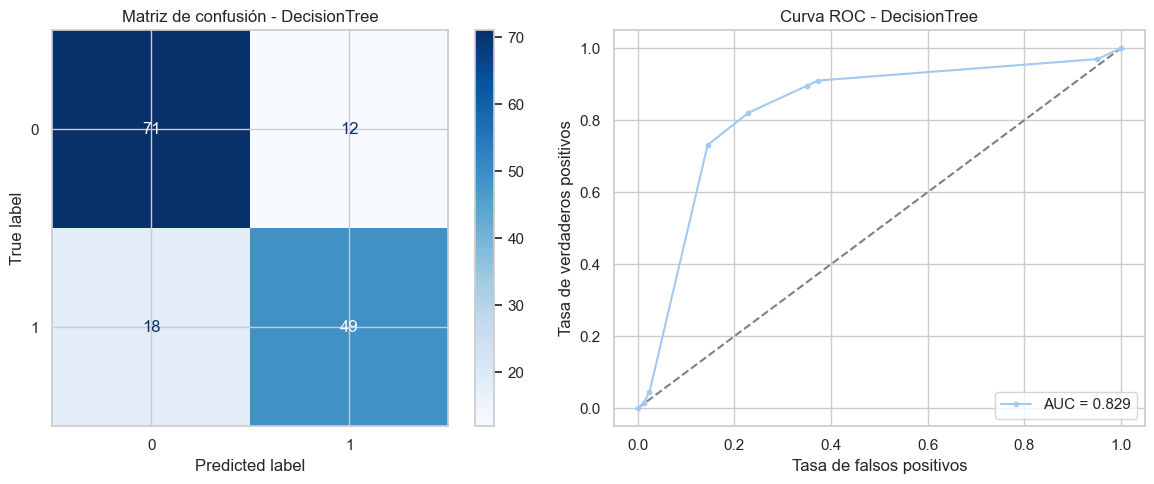


Métricas - DecisionTree
                          Valor
Exactitud              0.800000
AUC                    0.829078
Kappa                  0.591874
Precisión (PPV)        0.803279
Sensibilidad (Recall)  0.731343
F1                     0.765625
Especificidad          0.855422



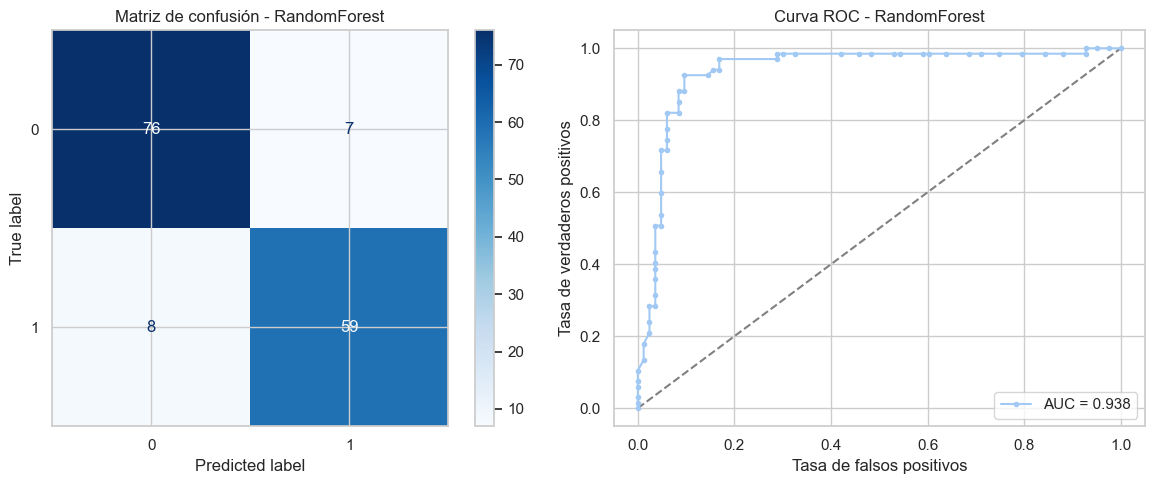


Métricas - RandomForest
                          Valor
Exactitud              0.900000
AUC                    0.937691
Kappa                  0.797407
Precisión (PPV)        0.893939
Sensibilidad (Recall)  0.880597
F1                     0.887218
Especificidad          0.915663



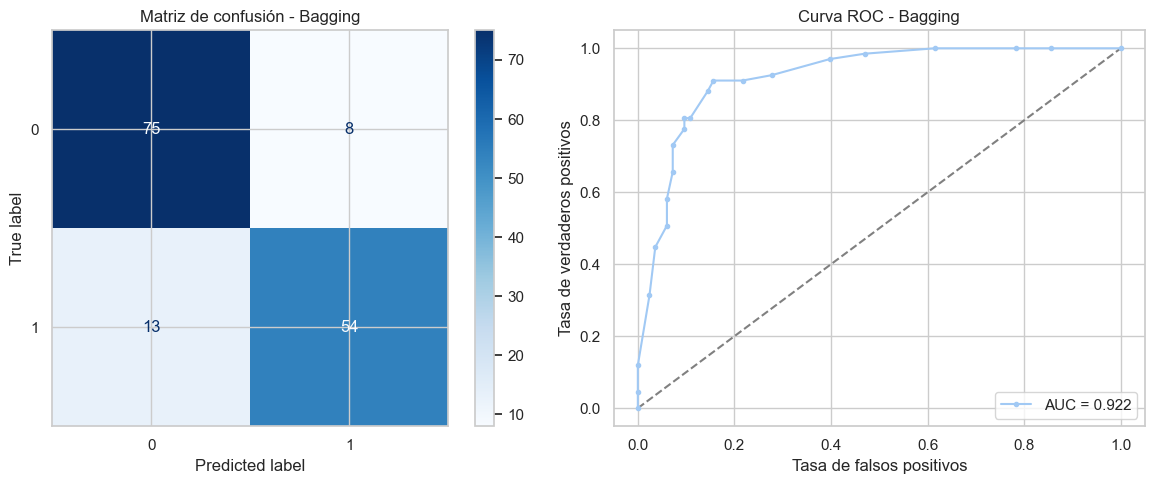


Métricas - Bagging
                          Valor
Exactitud              0.860000
AUC                    0.921956
Kappa                  0.714726
Precisión (PPV)        0.870968
Sensibilidad (Recall)  0.805970
F1                     0.837209
Especificidad          0.903614



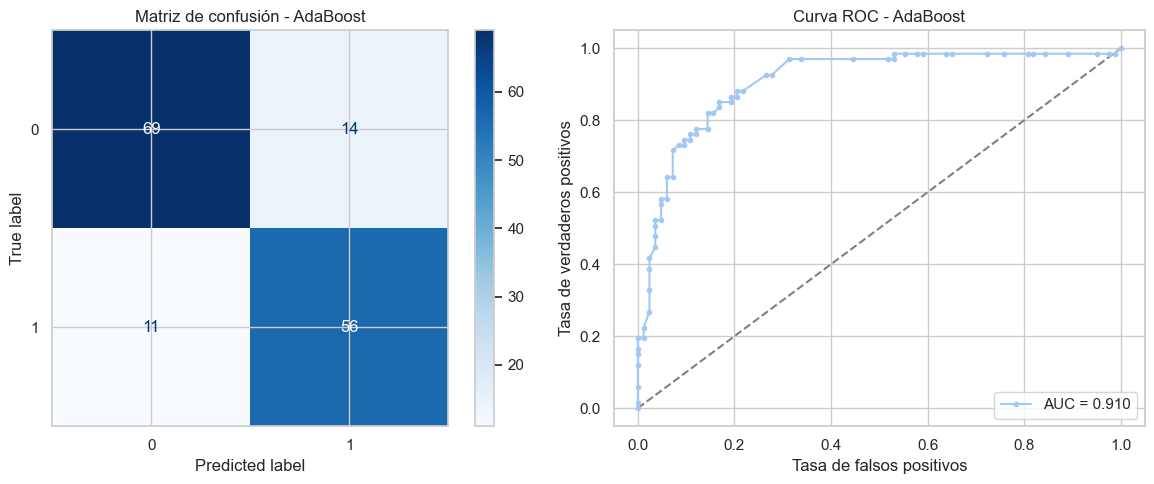


Métricas - AdaBoost
                          Valor
Exactitud              0.833333
AUC                    0.909639
Kappa                  0.664279
Precisión (PPV)        0.800000
Sensibilidad (Recall)  0.835821
F1                     0.817518
Especificidad          0.831325



In [77]:
all_metrics = {}
for name, grid_search in trained_models.items():
    all_metrics[name] = evaluate_model(grid_search, X_test, Y_test, name)

## Importancia de Variables

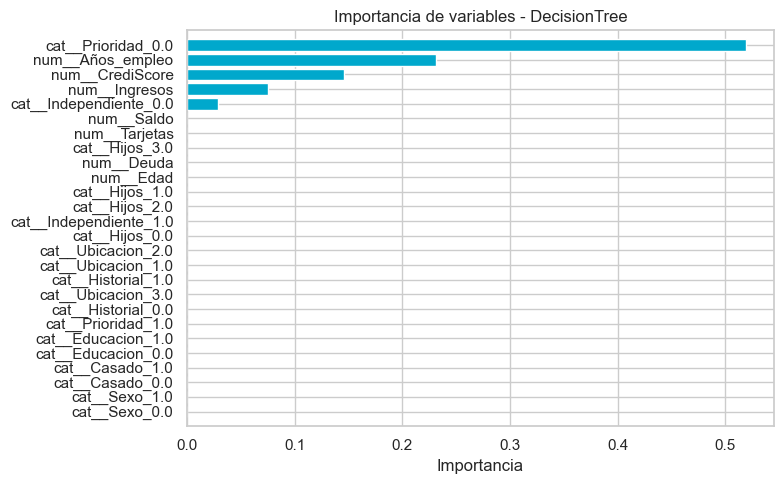

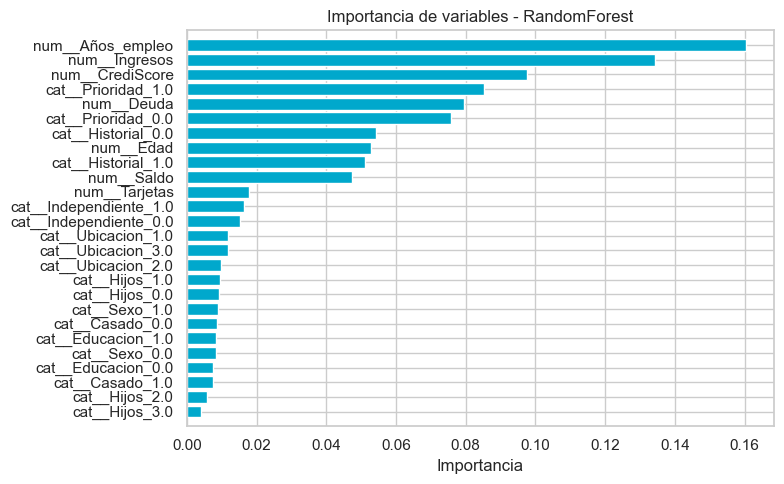

Bagging no soporta importancia de variables.


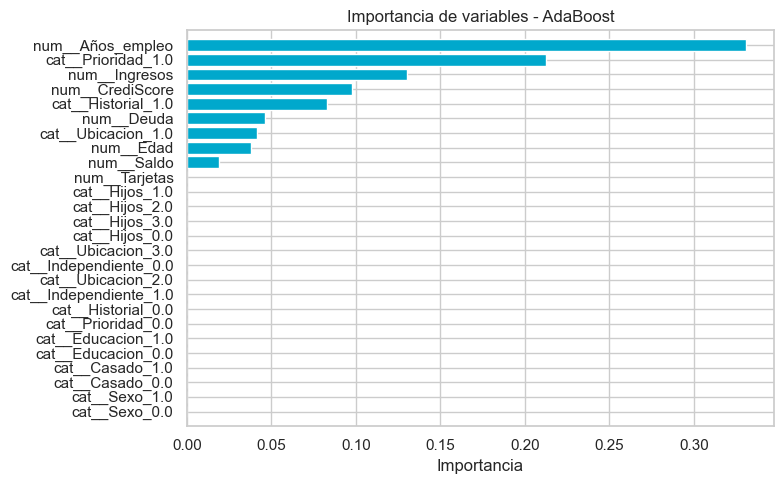

In [78]:
def plot_feature_importance(grid_search, name):
    model = grid_search.best_estimator_
    classifier = model.named_steps['classifier']

    if not hasattr(classifier, 'feature_importances_'):
        print(f"{name} no soporta importancia de variables.")
        return

    try:
        feature_names = model.named_steps['preprocessor'].get_feature_names_out()
    except Exception:
        feature_names = [f"feature_{i}" for i in range(len(classifier.feature_importances_))]
    feature_names = np.array(feature_names)
    importances = classifier.feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(8, 5))
    plt.title(f"Importancia de variables - {name}")
    plt.barh(range(len(indices)), importances[indices], align="center", color="#00a8cc")
    plt.yticks(range(len(indices)), feature_names[indices])
    plt.ylim([-1, len(indices)])
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()


for name, grid_search in trained_models.items():
    plot_feature_importance(grid_search, name)

## Validación Cruzada por Modelo

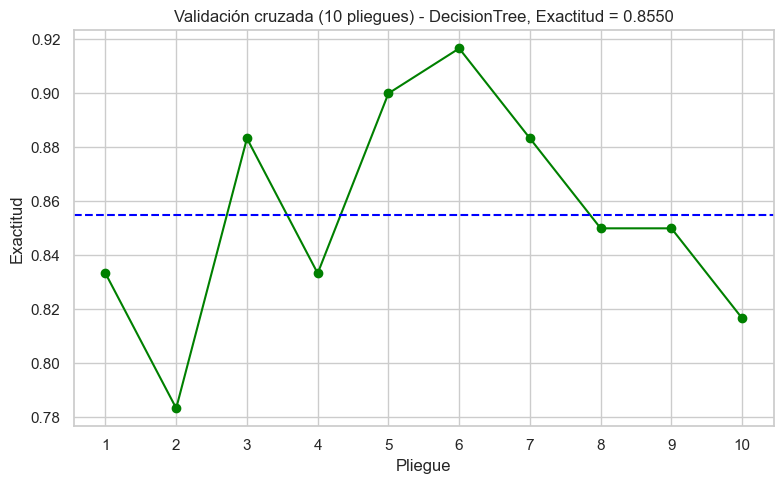

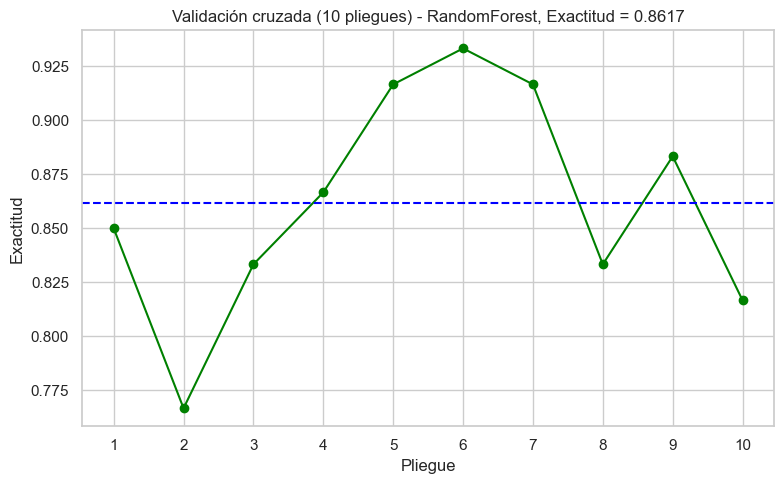

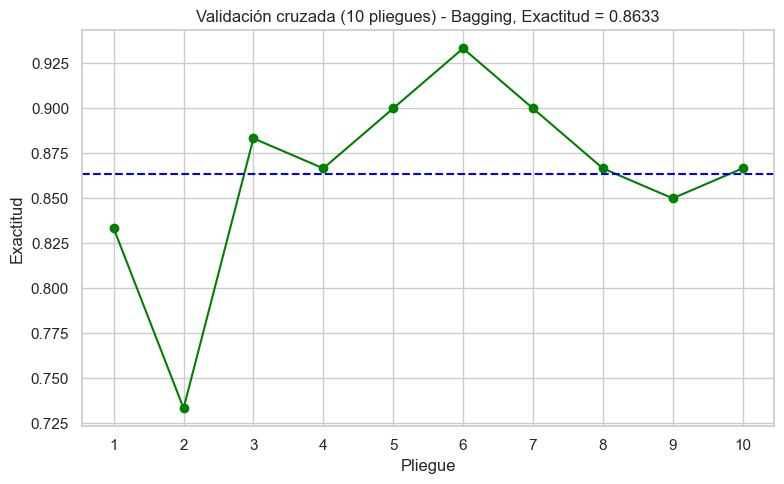

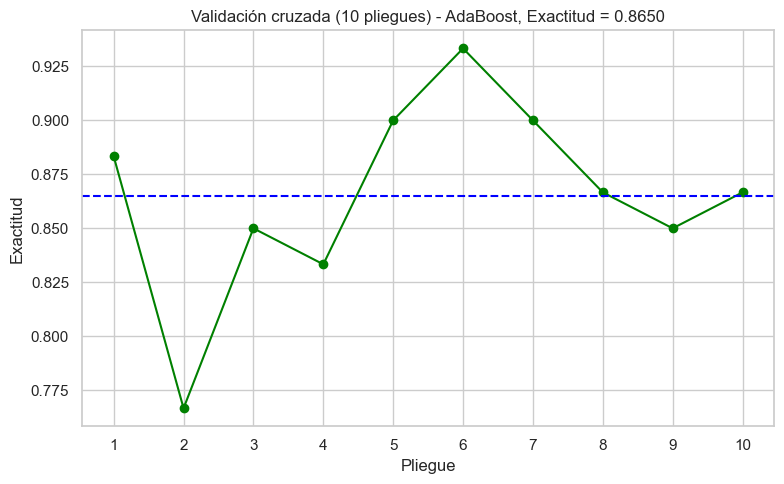

In [79]:
def plot_cv_results(grid_search, name):
    results = pd.DataFrame(grid_search.cv_results_)
    best_params = grid_search.best_params_

    mask = results['params'].apply(lambda p: all(p.get(k) == v for k, v in best_params.items()))
    split_cols = [c for c in results.columns if c.startswith('split') and c.endswith('_test_score')]
    cv_scores = results.loc[mask, split_cols].values.ravel()

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', color="green")
    plt.xticks(np.arange(1, len(cv_scores) + 1, step=1))
    plt.axhline(y=cv_scores.mean(), linestyle='--', color='blue')
    plt.title(f'Validación cruzada ({len(cv_scores)} pliegues) - {name}, Exactitud = {cv_scores.mean():.4f}')
    plt.grid(True)
    plt.xlabel('Pliegue')
    plt.ylabel('Exactitud')
    plt.tight_layout()
    plt.show()


for name, grid_search in trained_models.items():
    plot_cv_results(grid_search, name)

## Comparación de Modelos

In [80]:
cv_scores_df = pd.DataFrame()
for name, grid_search in trained_models.items():
    results = pd.DataFrame(grid_search.cv_results_)
    best_params = grid_search.best_params_
    mask = results['params'].apply(lambda p: all(p.get(k) == v for k, v in best_params.items()))
    split_cols = [c for c in results.columns if c.startswith('split') and c.endswith('_test_score')]
    cv_scores_df[name] = results.loc[mask, split_cols].values.ravel()

print("Puntuaciones de validación cruzada por modelo:")
display(cv_scores_df)

Puntuaciones de validación cruzada por modelo:


,DecisionTree,RandomForest,Bagging,AdaBoost
0,0.833333,0.850000,0.833333,0.883333
1,0.783333,0.766667,0.733333,0.766667
2,0.883333,0.833333,0.883333,0.850000
3,0.833333,0.866667,0.866667,0.833333
4,0.900000,0.916667,0.900000,0.900000
5,0.916667,0.933333,0.933333,0.933333
6,0.883333,0.916667,0.900000,0.900000
7,0.850000,0.833333,0.866667,0.866667
8,0.850000,0.883333,0.850000,0.850000
9,0.816667,0.816667,0.866667,0.866667


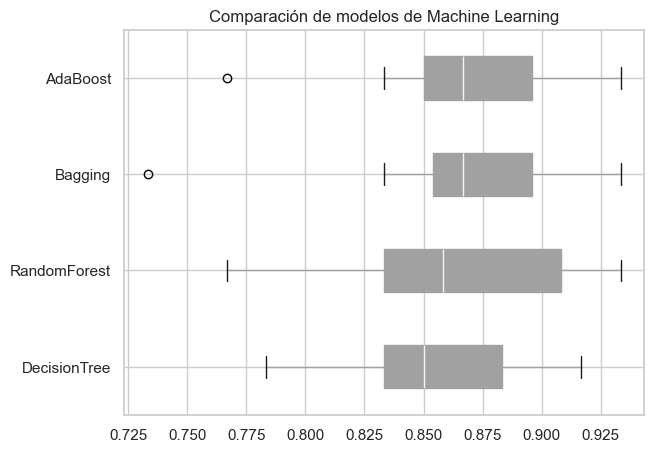

In [81]:
meds = cv_scores_df.median().sort_values()
df_sorted = cv_scores_df[meds.index]

fig = plt.figure(figsize=(8, 5))
plt.title('Comparación de modelos de Machine Learning')
df_sorted.boxplot(vert=False, patch_artist=True)
plt.subplots_adjust(left=0.25)
plt.show()

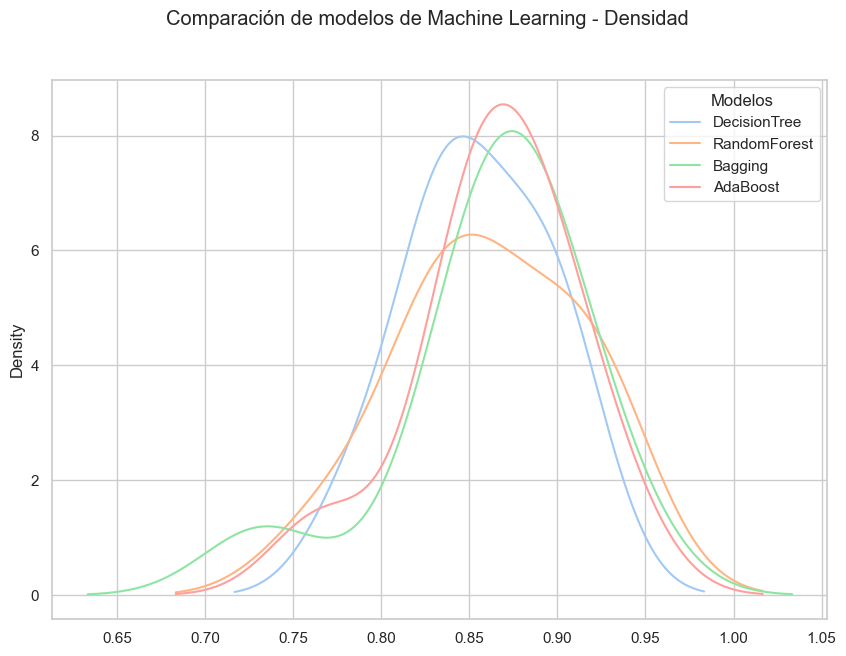

In [82]:
fig = plt.figure(figsize=(10, 7))
for col in cv_scores_df.columns:
    cv_scores_df[col].plot(kind='density')
fig.suptitle('Comparación de modelos de Machine Learning - Densidad')
plt.legend(loc="upper right", prop={'size': 11}, title="Modelos")
plt.show()

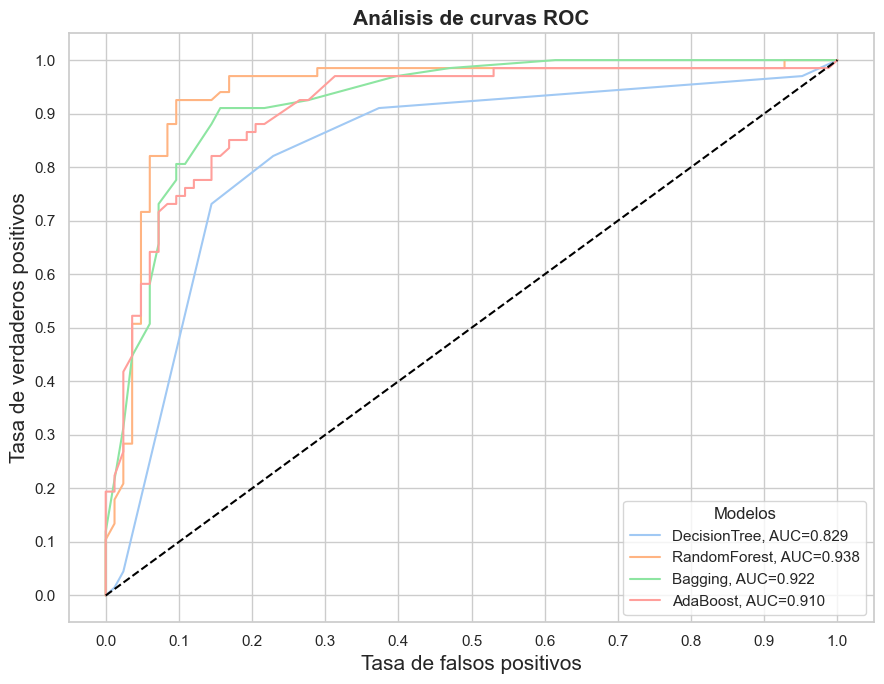

In [83]:
fig = plt.figure(figsize=(9, 7))

for name, grid_search in trained_models.items():
    model = grid_search.best_estimator_
    Y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, Y_proba)
    auc_val = roc_auc_score(Y_test, Y_proba)
    plt.plot(fpr, tpr, label=f"{name}, AUC={auc_val:.3f}")

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("Tasa de falsos positivos", fontsize=15)
plt.ylabel("Tasa de verdaderos positivos", fontsize=15)
plt.title('Análisis de curvas ROC', fontweight='bold', fontsize=15)
plt.legend(prop={'size': 11}, loc='lower right', title="Modelos")
plt.grid(True)
plt.tight_layout()
plt.show()

In [84]:
summary_rows = []
for name, grid_search in trained_models.items():
    model = grid_search.best_estimator_
    Y_pred = model.predict(X_test)
    test_acc = accuracy_score(Y_test, Y_pred)
    cv_acc = cv_scores_df[name].mean()
    summary_rows.append({"Modelo": name, "Exactitud prueba": test_acc, "Exactitud CV": cv_acc})

summary_df = pd.DataFrame(summary_rows).sort_values("Exactitud CV", ascending=False)
print(summary_df.to_string(index=False))

      Modelo  Exactitud prueba  Exactitud CV
    AdaBoost          0.833333      0.865000
     Bagging          0.860000      0.863333
RandomForest          0.900000      0.861667
DecisionTree          0.800000      0.855000


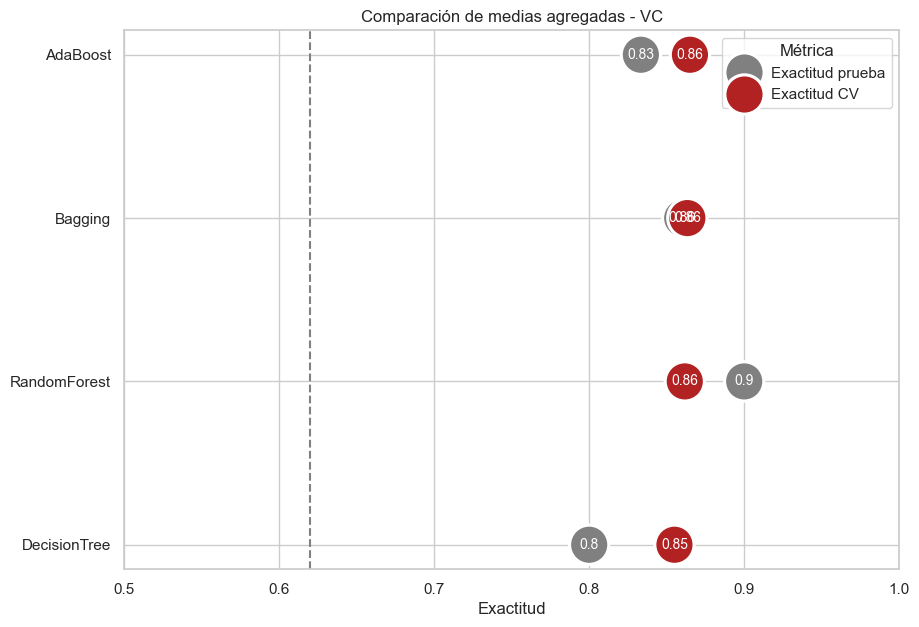

In [85]:
ds_melted = summary_df.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(10, 7))
sns.scatterplot(data=ds_melted, x='Valor', y='Modelo', hue='Métrica',
                s=800, palette={"Exactitud prueba": "gray", "Exactitud CV": "firebrick"})

for _, row in ds_melted.iterrows():
    plt.text(row['Valor'], row['Modelo'], round(row['Valor'], 2),
             color='white', size=10, ha='center', va='center')

plt.axvline(x=0.62, linestyle='--', color='grey')
plt.title('Comparación de medias agregadas - VC')
plt.xlabel('Exactitud')
plt.ylabel('')
plt.xlim(0.5, 1)
plt.show()